In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# **Evaluation**

## **1. Import các thư viện**

In [ ]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

import cv2
import os

import tensorflow as tf
from tensorflow.keras import layers, models, losses, optimizers

AUTOTUNE = tf.data.AUTOTUNE


## **2. Thiết lập đường dẫn các tệp**

Chúng ta khai báo các **đường dẫn tới các tệp dữ liệu và mô hình đã huấn luyện**, bao gồm:

* `model_path`: đường dẫn đến mô hình Siamese đã được huấn luyện và lưu dưới định dạng `.h5`.
* `history_path`: tệp `.csv` ghi lại lịch sử huấn luyện (loss và accuracy theo từng epoch).
* `test_csv_path`: danh sách các cặp ảnh vân tay dùng để đánh giá mô hình trên tập test. **(không dùng trong train)**
* `img_path`: thư mục chứa các ảnh vân tay đầu vào (dạng `.tif`, `.bmp`).


In [ ]:
model_path = '/content/drive/MyDrive/Fingerprint_Recognition/siamese_model_finally.h5'
history_path = '/content/drive/MyDrive/Fingerprint_Recognition/siamese_model_history.csv'
test_csv_path = '/content/drive/MyDrive/Fingerprint_Recognition/pairs_test.csv'
img_path = '/content/drive/MyDrive/Fingerprint_Recognition/Datasets/Fingerprint'

## **3. Load mô hình Siamese từ file `.h5`**



**Tải lại mô hình Siamese đã huấn luyện trước đó** từ đường dẫn `model_path`. Do mô hình sử dụng lớp Lambda với hàm khoảng cách `L1` (tính sai khác tuyệt đối giữa hai vector đặc trưng), chúng ta cần định nghĩa lại hàm `l1_distance` và truyền vào `custom_objects` khi gọi `load_model()`.


In [ ]:
import tensorflow as tf
from tensorflow.keras.models import load_model


# Hàm khoảng cách dùng trong mô hình
def l1_distance(vects):
    x, y = vects
    return tf.abs(x - y)

siamese_model = load_model(
    model_path,
    custom_objects={'l1_distance': l1_distance}
)


### Đọc lịch sử huấn luyện từ file `.csv`

**Đọc lại file CSV chứa lịch sử huấn luyện** của mô hình, bao gồm các chỉ số như:

* **`accuracy`**: độ chính xác trên tập huấn luyện theo từng epoch
* **`val_accuracy`**: độ chính xác trên tập validation
* **`loss`**: giá trị hàm mất mát (loss) trên tập huấn luyện
* **`val_loss`**: giá trị loss trên tập validation
* **`auc`**: chỉ số AUC (Area Under Curve) cho tập huấn luyện
* **`val_auc`**: AUC trên tập validation


Các chỉ số này là cơ sở quan trọng để đánh giá hiệu quả mô hình trong quá trình huấn luyện, đặc biệt hữu ích để phát hiện overfitting, underfitting trong mô hình.


In [ ]:
history_df = pd.read_csv(history_path)
history_df.head()

,accuracy,auc,loss,val_accuracy,val_auc,val_loss
0,0.657589,0.587600,0.488498,0.664811,0.739604,0.417892
1,0.696611,0.760710,0.393615,0.756648,0.810027,0.344493
2,0.795230,0.833016,0.342803,0.812925,0.847446,0.332308
3,0.832014,0.860114,0.318269,0.841064,0.861272,0.297195
4,0.857283,0.880056,0.295726,0.856524,0.875906,0.274167


### **1. Accuracy and Loss over epoch**
Biểu đồ bên trái thể hiện sự thay đổi độ chính xác (Accuracy) và bên phải thể hiện giá trị hàm mất mát (Loss) của mô hình qua từng epoch trong quá trình huấn luyện.
- **Đường màu cam**: Độ chính xác trên tập huấn luyện (Train).
- **Đường màu đỏ**: Độ chính xác trên tập validation (Validation).




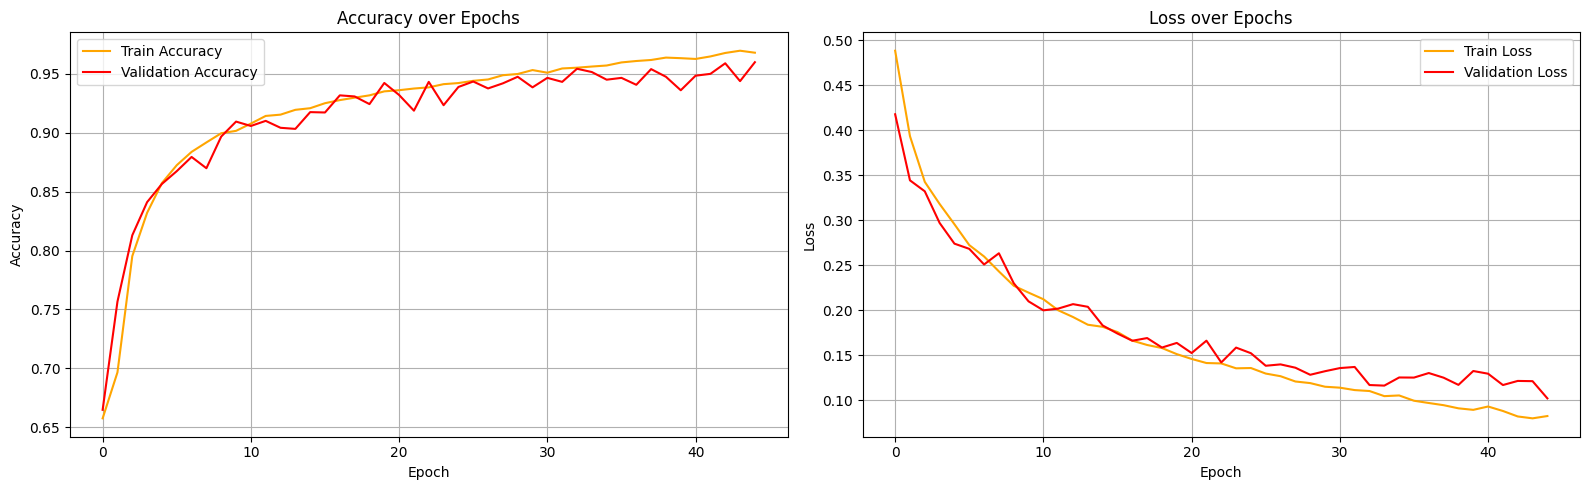

In [ ]:
def plot_accuracy_and_loss(df):
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    # Accuracy
    axes[0].plot(df['accuracy'], label='Train Accuracy', color='orange')
    axes[0].plot(df['val_accuracy'], label='Validation Accuracy', color='red')
    axes[0].set_title('Accuracy over Epochs')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()
    axes[0].grid(True)

    # Loss
    axes[1].plot(df['loss'], label='Train Loss', color='orange')
    axes[1].plot(df['val_loss'], label='Validation Loss', color='red')
    axes[1].set_title('Loss over Epochs')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].legend()
    axes[1].grid(True)

    plt.tight_layout()
    plt.show()

plot_accuracy_and_loss(history_df)



#### Nhận xét tổng quan: Accuracy & Loss over Epochs


Trong quá trình huấn luyện, cả **độ chính xác (accuracy)** và **hàm mất mát (loss)** đều cho thấy sự cải thiện ổn định theo từng epoch, phản ánh rõ chất lượng học tập của mô hình.

* **Train Accuracy** và **Validation Accuracy** cùng **tăng đều và đạt mức cao trên 0.95**, cho thấy mô hình học hiệu quả và chính xác. Validation Accuracy dao động nhẹ nhưng duy trì ổn định, **không có dấu hiệu giảm sút** – điều này cho thấy mô hình **không bị overfitting nghiêm trọng**.

* **Train Loss** và **Validation Loss** cũng **giảm đều và ổn định**, đặc biệt giảm mạnh trong **10 epoch đầu**, phản ánh tốc độ học tốt ở giai đoạn đầu. Sau đó, loss tiếp tục giảm ổn định, với Validation Loss dao động nhẹ và không có xu hướng tăng lại – **điều này cho thấy mô hình khá ổn định và không bị lệch**.

* Khoảng cách giữa train và validation (cả với accuracy lẫn loss) **rất nhỏ và gần như song song**, cho thấy mô hình **không bị học vẹt (memorization)** và có **khả năng khái quát hóa tốt**.

* Đặc biệt, từ **epoch 30 trở đi**, cả hai chỉ số chính xác và mất mát bắt đầu **hội tụ và tiệm cận**, có thể cân nhắc **early stopping** để tối ưu thời gian mà vẫn giữ hiệu năng cao.

* Tại cuối quá trình huấn luyện (**epoch 45**), mô hình đạt **Train Accuracy \~0.97**, **Validation Accuracy \~0.96**, **Train Loss < 0.1** và **Validation Loss \~0.1** – một kết quả **rất tích cực** cho bài toán phân loại nhị phân như xác minh dấu vân tay.

#### Kết luận:

Biểu đồ thể hiện rằng mô hình **học ổn định, không overfit, và có khả năng tổng quát tốt**. Đây là một nền tảng vững chắc để triển khai mô hình vào **bài toán xác thực dấu vân tay trong môi trường thực tế**, nơi yêu cầu độ chính xác và độ tin cậy cao.


### **2. AUC over Epochs**
Biểu đồ này theo dõi sự cải thiện của chỉ số AUC (Area Under Curve) theo thời gian huấn luyện.

- **AUC** đo lường khả năng phân biệt giữa hai lớp (match vs non-match)

- Càng gần 1.0 thì mô hình càng tốt

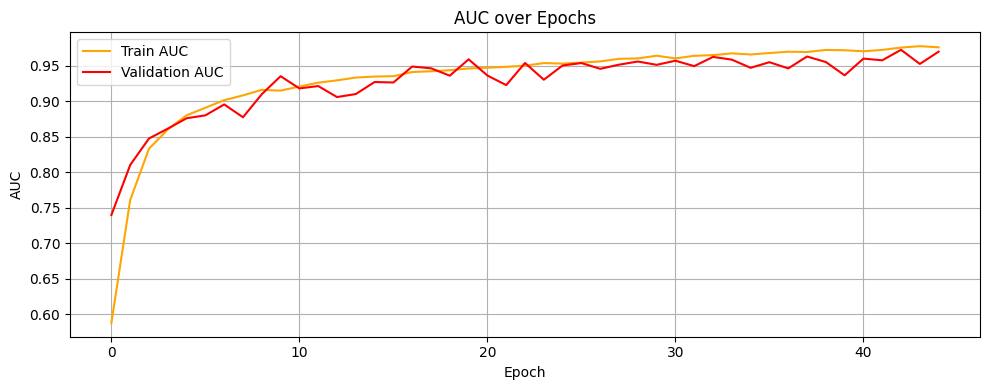

In [ ]:
def plot_auc(df):
    plt.figure(figsize=(10, 4))
    plt.plot(df['auc'], label='Train AUC', color='orange')
    plt.plot(df['val_auc'], label='Validation AUC', color='red')
    plt.title('AUC over Epochs')
    plt.xlabel('Epoch')
    plt.ylabel('AUC')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

plot_auc(history_df)

#### Nhận xét:

- Trong những epoch đầu tiên, AUC bắt đầu ở mức trung bình (**Train AUC \~0.58**, **Val AUC \~0.74**), sau đó **tăng nhanh và ổn định**, đặc biệt trong **10–15 epoch đầu**, phản ánh mô hình đã học được khả năng phân biệt giữa hai lớp rõ ràng.

- Từ epoch 15 trở đi, cả hai đường AUC bắt đầu tiệm cận và **duy trì ổn định quanh ngưỡng 0.95–0.97**, cho thấy mô hình **duy trì hiệu suất cao** trong việc phân loại. Đường Validation AUC có **dao động nhẹ**, nhưng luôn giữ ở mức rất cao – chứng tỏ mô hình **tổng quát hóa tốt** và **ít nhạy cảm với nhiễu** trên dữ liệu kiểm tra.

Tại cuối quá trình huấn luyện, **Validation AUC đạt đỉnh \~0.97**, đồng thời gần bằng với Train AUC, cho thấy mô hình **không bị overfitting** và **rất đáng tin cậy** trong môi trường thực tế.

#### Kết luận:

Biểu đồ AUC xác nhận rằng mô hình có **khả năng phân biệt vượt trội** giữa hai lớp dữ liệu. Với AUC đạt mức gần như tối đa, mô hình hoàn toàn có thể sử dụng cho các ứng dụng xác thực vân tay yêu cầu **độ chính xác cao và an toàn**.


## **4. Đánh giá mô hình trên tập test**

### **4.1 Đọc dữ liệu test và trực quan hóa phân bố nhãn**

In [ ]:
# Đọc file CSV chứa các cặp test
pairs_test_df = pd.read_csv(test_csv_path)

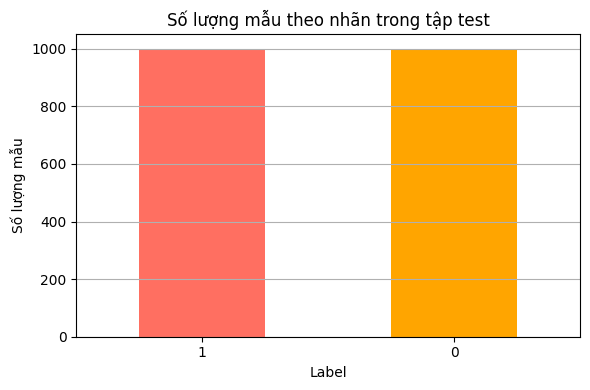

{1: 1000, 0: 1000}

In [ ]:
# Đếm số lượng nhãn 0 và nhãn 1
label_counts = pairs_test_df['label'].value_counts()

# Vẽ histogram
plt.figure(figsize=(6, 4))
label_counts.plot(kind='bar', color=['#ff6f61', '#ffa500'])
plt.title('Số lượng mẫu theo nhãn trong tập test')
plt.xlabel('Label')
plt.ylabel('Số lượng mẫu')
plt.xticks(rotation=0)
plt.grid(axis='y')
plt.tight_layout()
plt.show()

# Trả về số lượng từng nhãn
label_counts.to_dict()


### **4.2 Định nghĩa hàm xử lý ảnh đầu vào**


Tiền xử lý ảnh vân tay
- Ta định nghĩa các hàm để đọc, resize và chuẩn hóa ảnh grayscale về kích thước cố định (100x100).
- Ảnh được đọc từ cột img1 và img2 trong tập test. Đây là bước bắt buộc để đảm bảo đầu vào nhất quán với mô hình đã huấn luyện.

In [ ]:
# Resize ảnh
IMG_SIZE = 100

# Hàm đọc và tiền xử lý ảnh
def load_image(filename):
    path = os.path.join(img_path, filename)
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    img = img.astype("float32") / 255.0
    return img

def load_img_from_row(row):
    return load_image(row['img1']), load_image(row['img2'])

### **4.3 Load toàn bộ ảnh test bằng multi-thread**


- Sử dụng ThreadPoolExecutor để tăng tốc độ nạp ảnh bằng đa luồng, từ đó sinh ra hai mảng img1_test và img2_test chứa toàn bộ ảnh của tập test.
- Ảnh cũng được reshape để có định dạng (H, W, 1) — phù hợp với đầu vào của mạng nơ-ron.

In [ ]:
from concurrent.futures import ThreadPoolExecutor

with ThreadPoolExecutor() as executor:
    results = list(executor.map(load_img_from_row, [row for _, row in pairs_test_df.iterrows()]))

img1_test = np.array([r[0] for r in results])
img2_test = np.array([r[1] for r in results])
labels_test = pairs_test_df['label'].values.astype('float32')

# Thêm kênh cho ảnh grayscale
img1_test = img1_test[..., np.newaxis]
img2_test = img2_test[..., np.newaxis]

### **4.4 Tạo Dataset cho mô hình dự đoán**


- Tạo tf.data.Dataset từ ảnh và nhãn test đã chuẩn hóa.
- Chia batch và prefetch giúp tăng tốc độ dự đoán.

In [ ]:
# Tạo tf.data.Dataset
test_ds = tf.data.Dataset.from_tensor_slices(((img1_test, img2_test), labels_test))
test_ds = test_ds.batch(32).prefetch(AUTOTUNE)

### **4.5 Dự đoán và tính xác suất**

In [ ]:
from scipy.special import expit
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# Dự đoán toàn bộ test set trong một lệnh
logits = siamese_model.predict(test_ds, verbose=1)  # logits đầu ra
y_pred_probs = expit(logits.flatten())              # sigmoid chuyển logits thành xác suất

# Dự đoán nhị phân
y_pred = (y_pred_probs > 0.5).astype(int)

# Lấy ground truth từ test_ds
y_true = np.concatenate([y.numpy() for _, y in test_ds], axis=0)

# Đánh giá
print(classification_report(y_true, y_pred, digits=4))
print("Confusion Matrix:\n", confusion_matrix(y_true, y_pred))
print("ROC AUC Score:", roc_auc_score(y_true, y_pred_probs))


63/63 ━━━━━━━━━━━━━━━━━━━━ 20s 317ms/step
              precision    recall  f1-score   support

         0.0     0.9353    0.9680    0.9514      1000
         1.0     0.9668    0.9330    0.9496      1000

    accuracy                         0.9505      2000
   macro avg     0.9511    0.9505    0.9505      2000
weighted avg     0.9511    0.9505    0.9505      2000

Confusion Matrix:
 [[968  32]
 [ 67 933]]
ROC AUC Score: 0.991366


### **4.6 Trực quan hóa kết quả dự đoán bằng ROC Curve và Precision-Recall Curve**

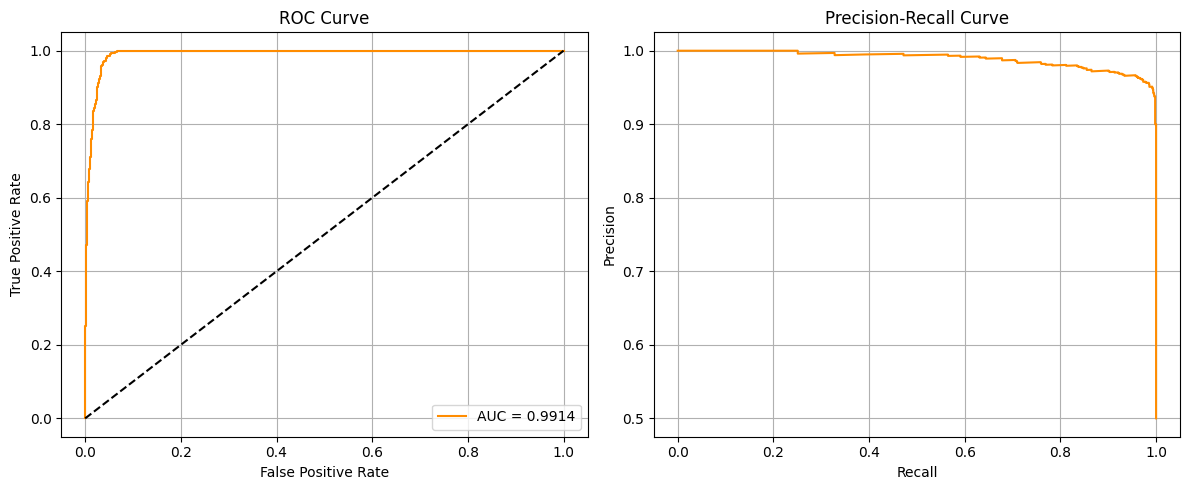

In [ ]:
from sklearn.metrics import roc_curve, auc, precision_recall_curve

# Tính các giá trị từ kết quả dự đoán
fpr, tpr, _ = roc_curve(y_true, y_pred_probs)
roc_auc = auc(fpr, tpr)
precision, recall, _ = precision_recall_curve(y_true, y_pred_probs)

# Vẽ 2 biểu đồ cạnh nhau
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

# ROC Curve
axs[0].plot(fpr, tpr, color='darkorange', label=f'AUC = {roc_auc:.4f}')
axs[0].plot([0, 1], [0, 1], 'k--')
axs[0].set_title('ROC Curve')
axs[0].set_xlabel('False Positive Rate')
axs[0].set_ylabel('True Positive Rate')
axs[0].legend()
axs[0].grid(True)

# Precision-Recall Curve
axs[1].plot(recall, precision, color='darkorange')
axs[1].set_title('Precision-Recall Curve')
axs[1].set_xlabel('Recall')
axs[1].set_ylabel('Precision')
axs[1].grid(True)

plt.tight_layout()
plt.show()


#### 1. **ROC Curve (Bên trái)**

Biểu đồ ROC thể hiện mối quan hệ giữa:

* **True Positive Rate (Recall)** – tỷ lệ dự đoán đúng cặp giống nhau
* **False Positive Rate** – tỷ lệ nhầm lẫn cặp khác nhau thành giống

Kết quả:

- **AUC = 0.9914**, rất gần 1.0, chứng tỏ mô hình **có khả năng phân biệt cực kỳ tốt giữa hai lớp**.
- Đường cong ROC **cong mạnh về góc trên trái**, cho thấy mô hình **duy trì độ chính xác cao** ngay cả khi giữ tỷ lệ nhầm lẫn ở mức thấp. Điều này đặc biệt quan trọng trong các bài toán xác thực như sinh trắc học, nơi **nhầm người lạ thành người quen là rủi ro nghiêm trọng**.

#### 2. **Precision–Recall Curve (Bên phải)**

Biểu đồ Precision–Recall tập trung vào:

* **Recall** – khả năng không bỏ sót cặp giống nhau
* **Precision** – tỷ lệ chính xác trong các cặp được mô hình cho là giống

Kết quả:

* **Precision duy trì khá cao trên 0.95** trong hầu hết dải Recall → mô hình **gần như rất ít nhầm nhãn 0 thành nhãn 1**
* Ngay cả khi Recall tăng cao (đến gần 1.0), Precision vẫn **giữ trên 0.95**, cho thấy khả năng phân biệt cực kỳ mạnh mẽ và ổn định
* Đường cong có hình dáng “vuông góc trên phải” lý tưởng, thể hiện **hiệu suất mô hình rất cao**

---

### Kết luận:

> Cả hai biểu đồ đều chỉ ra rằng mô hình Siamese **hoạt động xuất sắc trên tập test**, không chỉ **phân biệt rất tốt giữa hai nhãn**, mà còn **duy trì tính ổn định và đáng tin cậy trong toàn bộ không gian ngưỡng (threshold)**. Đây là bằng chứng rõ ràng cho thấy mô hình có thể **triển khai vào thực tế** trong các ứng dụng xác thực vân tay, nơi yêu cầu độ chính xác và độ tin cậy cao.



### **4.7 Lựa chọn Threshold tối ưu**
Phân tích TPR và TNR theo Ngưỡng Threshold giúp lựa chọn ngưỡng phân loại (threshold) tối ưu cho mô hình.

In [ ]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_true, y_pred_probs)

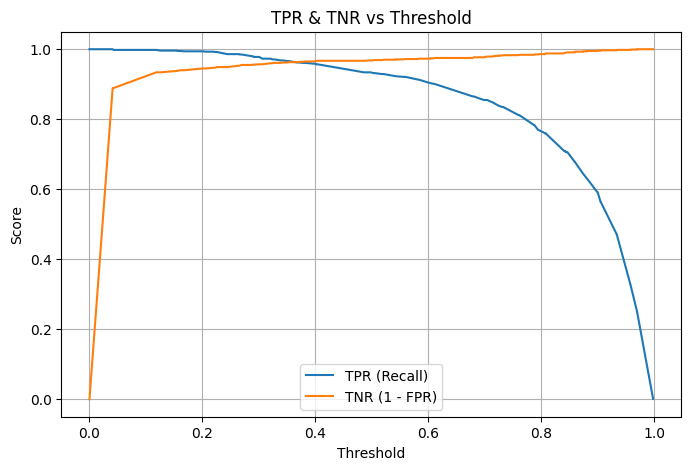

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(thresholds, tpr, label='TPR (Recall)')
plt.plot(thresholds, 1 - fpr, label='TNR (1 - FPR)')
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("TPR & TNR vs Threshold")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
# Precision-Recall curve
precisions, recalls, thresholds_pr = precision_recall_curve(y_true, y_pred_probs)

# Tìm threshold sao cho precision ≥ 98%
target_precision = 0.98
indices = np.where(precisions >= target_precision)[0]

if len(indices) == 0:
    print("⚠️ Không có threshold nào đạt precision ≥ 98%")
    threshold_98 = 0.5  # fallback
else:
    best_index = indices[0]
    threshold_98 = thresholds_pr[best_index]
    print(f"✅ Threshold đạt precision ≥ 98%: {threshold_98:.4f}")

✅ Threshold đạt precision ≥ 98%: 0.7324


In [ ]:
from sklearn.metrics import precision_score
# Dự đoán nhị phân với threshold mới
y_pred_98 = (y_pred_probs > threshold_98).astype(int)

# Confusion matrix và precision thực tế
cm = confusion_matrix(y_true, y_pred_98)
precision_real = precision_score(y_true, y_pred_98)

print("Confusion Matrix (với threshold precision ≥ 98%):")
print(cm)
print(f"Precision đạt được: {precision_real:.4f}")

Confusion Matrix (với threshold precision ≥ 98%):
[[983  17]
 [166 834]]
Precision đạt được: 0.9800


### Ta sẽ chọn **threshold = 0.73**

Trong bài toán phân loại nhị phân như so khớp dấu vân tay (match vs non-match), việc chọn ngưỡng (threshold) phù hợp đóng vai trò rất quan trọng vì ảnh hưởng trực tiếp đến:

* **Tỷ lệ phát hiện đúng các cặp giống nhau TPR (Recall)**
* **Tỷ lệ tránh nhầm các cặp khác nhau thành giống nhau TNR (1 - FPR)**

#### Với threshold = 0.73 ?

Dựa vào biểu đồ **TPR & TNR theo threshold**, ta thấy rằng:

* Tại **threshold này**, đường **TNR (1 - FPR)** đã tiệm cận mức tối đa → tức là **mô hình rất hiếm khi nhầm lẫn cặp không giống thành giống.**
* Đồng thời, TPR vẫn duy trì ở mức ~83%, tức mô hình vẫn **phát hiện được phần lớn các cặp giống nhau.**



In [ ]:
threshould = threshold_98

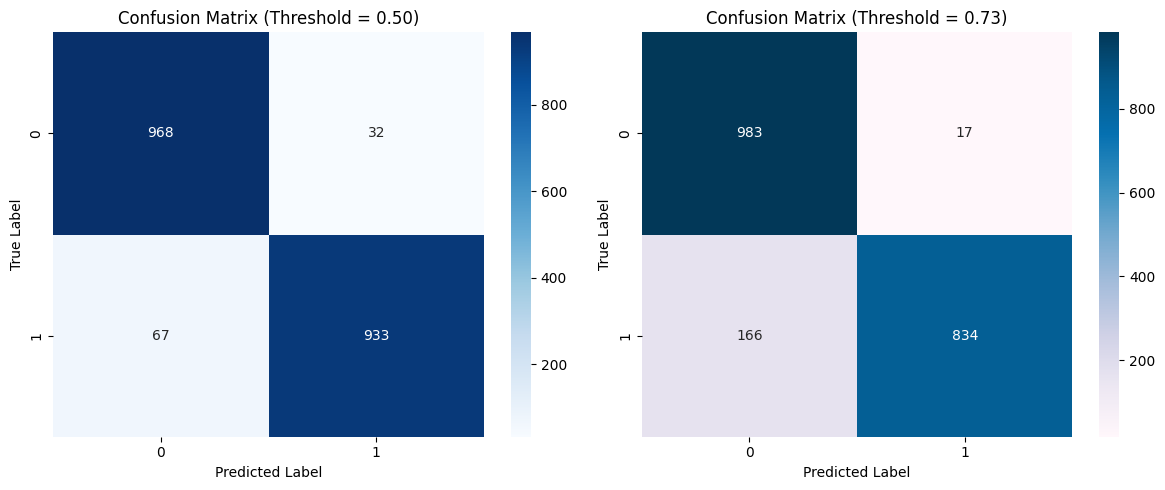

In [ ]:
# Dự đoán với threshold mặc định (0.5)
cm_50 = confusion_matrix(y_true, y_pred)

# Vẽ 2 confusion matrix cạnh nhau
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

# Confusion Matrix - Threshold 0.50
sns.heatmap(cm_50, annot=True, fmt='d', cmap='Blues', ax=axs[0])
axs[0].set_title('Confusion Matrix (Threshold = 0.50)', fontsize=12)
axs[0].set_xlabel('Predicted Label')
axs[0].set_ylabel('True Label')

# Confusion Matrix - Threshold 0.73
sns.heatmap(cm, annot=True, fmt='d', cmap='PuBu', ax=axs[1])
axs[1].set_title('Confusion Matrix (Threshold = 0.73)', fontsize=12)
axs[1].set_xlabel('Predicted Label')
axs[1].set_ylabel('True Label')

plt.tight_layout()
plt.show()


In [ ]:
# Classification report cho threshold = 0.50
report_50 = classification_report(y_true, y_pred, digits=4)

# Classification report cho threshold = 0.73
report_98 = classification_report(y_true, y_pred_98, digits=4)

print(report_50)
print(report_98)


              precision    recall  f1-score   support

         0.0     0.9353    0.9680    0.9514      1000
         1.0     0.9668    0.9330    0.9496      1000

    accuracy                         0.9505      2000
   macro avg     0.9511    0.9505    0.9505      2000
weighted avg     0.9511    0.9505    0.9505      2000

              precision    recall  f1-score   support

         0.0     0.8555    0.9830    0.9148      1000
         1.0     0.9800    0.8340    0.9011      1000

    accuracy                         0.9085      2000
   macro avg     0.9178    0.9085    0.9080      2000
weighted avg     0.9178    0.9085    0.9080      2000



**So sánh giữa hai ngưỡng dự đoán**: **Threshold = 0.5 (mặc định)** và **Threshold = 0.73 (chọn theo precision 98%)** dựa trên **Confusion Matrix** và **Classification Report**:

---

#### So sánh Hiệu suất Mô hình theo Threshold

| Chỉ số             | **Threshold = 0.5** | **Threshold = 0.73**       |
| ------------------ | ------------------- | ------------------------- |
| **Accuracy**       | 95.05%              | 90.85%                    |
| **Precision (0)**  | 93.53%              | 85.55%                    |
| **Recall (0)**     | **96.80%**         | **98.30%**  *(tăng)* |
| **Precision (1)**  | **96.68%**        | **98.00%**  *(đạt mục tiêu)* |
| **Recall (1)**     | **93.30%**          | **83.40%**  *(đánh đổi)*     |
| **F1-score (avg)** | 0.9505              | 0.9085                    |

---

### So sánh Confusion Matrix

|                         | **Threshold 0.5** | **Threshold 0.73** |
| ----------------------- | ----------------- | ----------------- |
| **True Negative (TN)**  | 968               | **983**  *(+15)*  |
| **False Positive (FP)** | 32                | **17**  *(−15)*   |
| **False Negative (FN)** | **67**  *(thấp)* | 166 *(+99)*       |
| **True Positive (TP)**  | **933**          | 834  *(giảm)*    |

---

### Nhận xét:

* **Threshold = 0.5** có:

  * Tỷ lệ phát hiện đúng nhãn 1 (Recall = 93.3%) cao hơn
  * Độ chính xác tổng thể tốt hơn (**accuracy = 95.05%**)
  * Mô hình cân bằng giữa precision và recall

* **Threshold = 0.73 (precision 98%)** có:

  * Mô hình trở nên **bảo thủ** hơn trong việc xác nhận 2 ảnh là cùng dấu vân tay:

    * **Precision của nhãn 1 tăng lên 98%** → Giảm tối đa các dự đoán nhầm "cùng ngón" (sai dương tính).
    * **False Positive giảm mạnh**, tăng độ tin cậy khi mô hình nói “2 ảnh là giống nhau”.
  * Tuy nhiên, **Recall giảm mạnh (từ 93.3% → 83.4%)**, tức mô hình **bỏ sót nhiều cặp trùng khớp** hơn.
  * Tổng thể **F1-score và accuracy đều giảm**, phản ánh sự đánh đổi giữa tính chính xác và khả năng phát hiện.

---

### Kết luận:

> Việc lựa chọn **threshold = 0.73 nhằm đạt precision 98%** là **sự đánh đổi có chủ đích**. Với **ngưỡng 0.73**, mô hình trở nên **bảo thủ hơn**, ít nhầm lẫn hơn khi xác nhận dấu vân tay là giống nhau. Điều này đặc biệt quan trọng trong các ứng dụng nhạy cảm như **bảo mật, xác thực, truy vết sinh trắc học**, nơi mà xác nhận nhầm hai người là giống nhau có thể gây hậu quả nghiêm trọng.

> Tuy nhiên, điều này dẫn đến việc bỏ sót một số trường hợp đúng (FN tăng). Lựa chọn ngưỡng phù hợp tùy thuộc vào **mức độ chấp nhận rủi ro của hệ thống thực tế**.



## **5. Kiểm thử mô hình với hai ảnh bất kỳ từ thư mục tùy chọn**

hai hàm `load_image_from_path()` và `predict_two_images()` được sử dụng để kiểm tra mô hình trên **ảnh thực tế** không nằm trong dataset gốc:

#### `load_image_from_path(path)`:

* Đọc ảnh grayscale từ một đường dẫn cụ thể.
* Thực hiện resize về kích thước chuẩn `IMG_SIZE × IMG_SIZE`.
* Xử lý ngoại lệ nếu ảnh không tồn tại hoặc lỗi đọc ảnh.

#### `predict_two_images(img_path_1, img_path_2, threshold)`:

* Tiếp nhận **đường dẫn ảnh vân tay** bất kỳ.
* Trả về:

  * **Giá trị logit** từ mô hình
  * **Xác suất giống nhau** sau khi qua hàm sigmoid
  * **Kết luận rõ ràng**: hai ảnh có cùng ngón tay không (dựa vào `threshold` do người dùng chỉ định, mặc định là 0.6)

Hàm này hỗ trợ kiểm thử thực tế với **ảnh ngoài tập huấn luyện**, giúp đánh giá độ linh hoạt và khả năng tổng quát hóa của mô hình.


In [ ]:
def load_image_from_path(path):
    if not os.path.exists(path):
        raise FileNotFoundError(f"Không tìm thấy file: {path}")

    try:
        img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        img = img.astype("float32") / 255.0
        return img
    except Exception as e:
        raise ValueError(f"Lỗi khi đọc ảnh {path}: {e}")



In [ ]:
from PIL import Image
def predict_two_images(img_path_1, img_path_2, threshold=threshold_98):
    """
    Dự đoán xem hai ảnh vân tay bất kì có giống nhau không.

    Parameters:
        img_path_1 (str): Đường dẫn file ảnh 1
        img_path_2 (str): Đường dẫn file ảnh 2
        threshold (float): Ngưỡng xác suất để phân loại giống nhau hay khác nhau (default: threshold_98)

    Output:
        In ra logit, xác suất và kết luận.
    """

    # Hiển thị 2 ảnh
    # Mở ảnh gốc bằng PIL để hiển thị nguyên vẹn
    img1_pil = Image.open(img_path_1).convert('L')
    img2_pil = Image.open(img_path_2).convert('L')

    # Hiển thị ảnh gốc
    fig, axs = plt.subplots(1, 2, figsize=(6, 3))
    axs[0].imshow(img1_pil, cmap='gray')
    axs[0].axis('off')
    axs[0].set_title("Ảnh 1")

    axs[1].imshow(img2_pil, cmap='gray')
    axs[1].axis('off')
    axs[1].set_title("Ảnh 2")

    plt.tight_layout()
    plt.show()

    img1 = load_image_from_path(img_path_1)[np.newaxis, ..., np.newaxis]
    img2 = load_image_from_path(img_path_2)[np.newaxis, ..., np.newaxis]

    logit = siamese_model.predict([img1, img2])[0][0]
    prob = expit(logit)

    print("So sánh hai ảnh vân tay:")
    print(f"→ Ảnh 1: {img_path_1}")
    print(f"→ Ảnh 2: {img_path_2}")
    print(f"→ Logit: {logit:.4f}")
    print(f"→ Xác suất giống nhau: {prob:.4f}")
    print(f"→ Kết luận: {'✅ Cùng ngón' if prob >= threshold else '❌ Khác ngón'}")


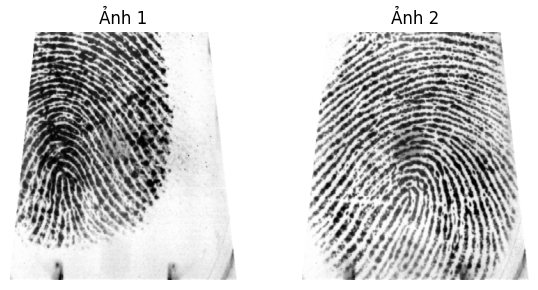

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
So sánh hai ảnh vân tay:
→ Ảnh 1: /content/076_7_1.tif
→ Ảnh 2: /content/076_5_4.tif
→ Logit: -11.2839
→ Xác suất giống nhau: 0.0000
→ Kết luận: ❌ Khác ngón


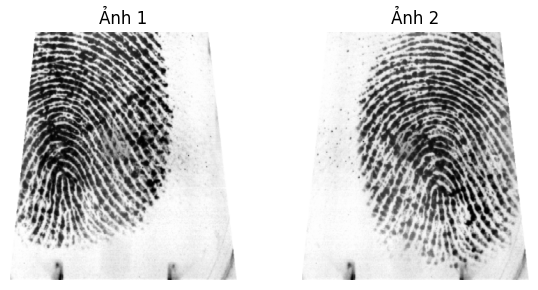

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step
So sánh hai ảnh vân tay:
→ Ảnh 1: /content/076_7_1.tif
→ Ảnh 2: /content/076_7_5.tif
→ Logit: 4.6554
→ Xác suất giống nhau: 0.9906
→ Kết luận: ✅ Cùng ngón


In [ ]:
predict_two_images("/content/076_7_1.tif", "/content/076_5_4.tif")
predict_two_images("/content/076_7_1.tif", "/content/076_7_5.tif")


## **6. Tìm top K ảnh vân tay giống nhất từ Database**

Hàm `find_top_k_matches_batch()` được sử dụng để tìm ra **top K ảnh trong thư mục database có độ giống cao nhất** với một ảnh truy vấn đầu vào.

#### Các bước thực hiện:

* Ảnh truy vấn được tải lên và xử lý (grayscale + resize + chuẩn hóa).
* Duyệt toàn bộ thư viện ảnh trong thư mục `gallery_folder`, đọc và xử lý mỗi ảnh tương tự.
* Sau đó:

  * Tạo **batch ảnh truy vấn lặp lại** với số lượng bằng số ảnh trong thư viện.
  * Dự đoán **song song trên GPU**, cho toàn bộ cặp ảnh `(query, candidate)` cùng lúc.
  * Chuyển kết quả logit sang xác suất qua sigmoid.
  * Trả về **top K ảnh có xác suất giống cao nhất**.


Hàm này cực kỳ hữu ích trong bài toán **so khớp vân tay (fingerprint retrieval)**, giúp tìm kiếm nhanh các mẫu giống nhau từ một thư viện lớn. Đồng thời, nhờ xử lý batch toàn phần, nó **tối ưu tốc độ** và tận dụng tốt GPU trong inference.


In [ ]:
from tqdm import tqdm

def find_top_k_matches_batch(model, query_path, gallery_folder, img_size=100, top_k=5, verbose=True, show_images=False):
    """
    Tìm top-k ảnh trong gallery giống với ảnh truy vấn.

    Params:
        model: mô hình Siamese đã huấn luyện
        query_path: đường dẫn ảnh truy vấn
        gallery_folder: thư mục chứa ảnh gallery
        img_size: kích thước ảnh resize
        top_k: số ảnh giống nhất cần trả về
        verbose: in kết quả ra console
        show_images: nếu True thì hiển thị ảnh truy vấn + top-k ảnh giống nhất

    Returns:
        Danh sách (filename, probability) của top-k ảnh giống nhất
    """

    # Tải và chuẩn bị ảnh truy vấn
    query_img_raw = load_image_from_path(query_path)
    query_img_resized = cv2.resize(query_img_raw, (img_size, img_size))
    query_img = np.expand_dims(query_img_resized, axis=(0, -1))

    gallery_imgs = []
    gallery_names = []

    for filename in tqdm(os.listdir(gallery_folder), desc="Đang tải gallery"):
        if filename.lower().endswith((".tif", ".bmp", ".png")):
            try:
                img = load_image_from_path(os.path.join(gallery_folder, filename))
                img = cv2.resize(img, (img_size, img_size))
                img = np.expand_dims(img, axis=-1)
                gallery_imgs.append(img)
                gallery_names.append(filename)
            except Exception as e:
                print(f"⚠️  Bỏ qua {filename}: {e}")

    gallery_imgs = np.array(gallery_imgs)
    num_gallery = len(gallery_imgs)

    query_batch = np.repeat(query_img, repeats=num_gallery, axis=0)

    logits = model.predict([query_batch, gallery_imgs], batch_size=64, verbose=0)
    probs = expit(logits.flatten())

    similarities = list(zip(gallery_names, probs))
    top_matches = sorted(similarities, key=lambda x: -x[1])[:top_k]

    if verbose:
        print(f"\nTop {top_k} ảnh giống nhất với {os.path.basename(query_path)}:")
        for i, (fname, prob) in enumerate(top_matches, 1):
            print(f"{i}. {fname} → Xác suất giống: {prob:.4f}")

    if show_images:
        fig, axs = plt.subplots(1, top_k + 1, figsize=(3 * (top_k + 1), 3))

        # Ảnh truy vấn
        axs[0].imshow(query_img_raw, cmap='gray')
        axs[0].set_title("Truy vấn")
        axs[0].axis("off")

        # Top-k ảnh gallery
        for i, (fname, prob) in enumerate(top_matches, start=1):
            img_path = os.path.join(gallery_folder, fname)
            img = load_image_from_path(img_path)
            axs[i].imshow(img, cmap='gray')
            axs[i].set_title(f"{fname}\n{prob:.2f}")
            axs[i].axis("off")

        plt.tight_layout()
        plt.show()

    return top_matches


Đang tải gallery: 100%|██████████| 65/65 [00:47<00:00,  1.37it/s]



Top 5 ảnh giống nhất với 013_8_2.tif:
1. 013_8_1.tif → Xác suất giống: 0.9770
2. 013_4_1.tif → Xác suất giống: 0.4492
3. 013_2_1.tif → Xác suất giống: 0.2556
4. 013_9_1.tif → Xác suất giống: 0.1829
5. 012_6_1.tif → Xác suất giống: 0.1147


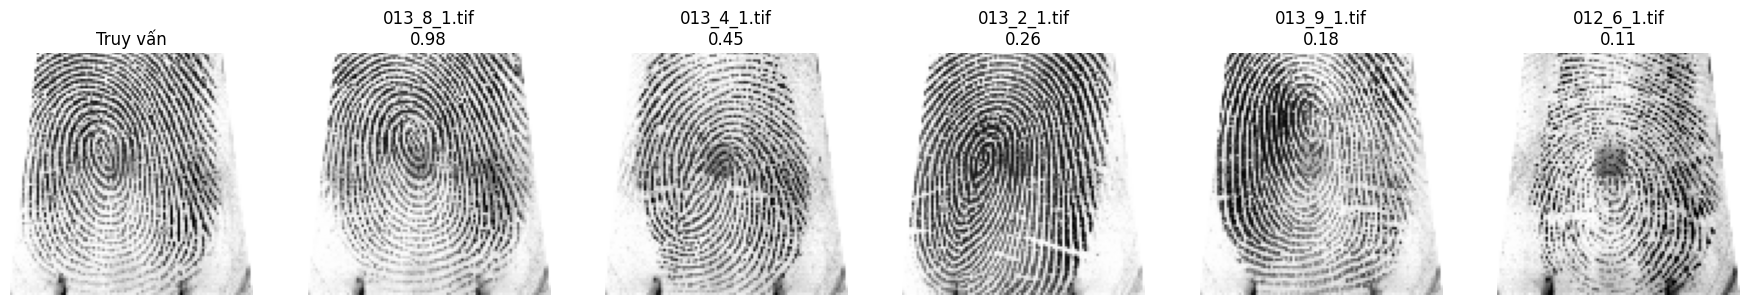

In [ ]:
gallery_path = "/content/drive/MyDrive/Fingerprint_Recognition/Datasets/Database"
query_path = "/content/drive/MyDrive/Fingerprint_Recognition/Datasets/Fingerprint/013_8_2.tif"

top_k = find_top_k_matches_batch(
    model=siamese_model,
    query_path=query_path,
    gallery_folder=gallery_path,
    img_size=100,
    top_k=5,
    show_images=True
)


Đang tải gallery: 100%|██████████| 65/65 [00:00<00:00, 112.39it/s]



Top 5 ảnh giống nhất với 057_5_3.tif:
1. 057_5_1.tif → Xác suất giống: 0.8687
2. 022_5_1.tif → Xác suất giống: 0.1584
3. 027_6_1.tif → Xác suất giống: 0.1298
4. 013_5_1.tif → Xác suất giống: 0.0183
5. 076_5_1.tif → Xác suất giống: 0.0146


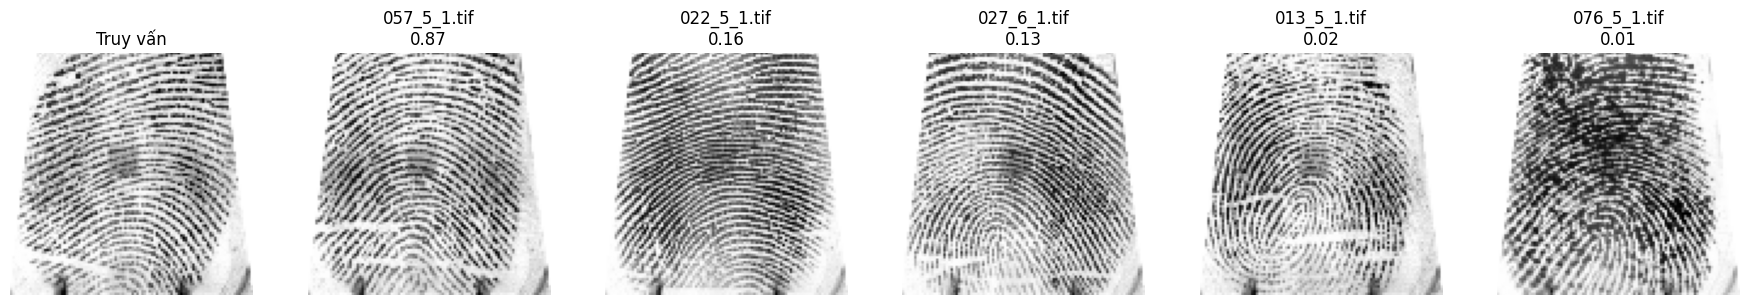

In [ ]:
query_path = "/content/drive/MyDrive/Fingerprint_Recognition/Datasets/Fingerprint/057_5_3.tif"

top_k = find_top_k_matches_batch(
    model=siamese_model,
    query_path=query_path,
    gallery_folder=gallery_path,
    img_size=100,
    top_k=5,
    show_images=True
)

Đang tải gallery: 100%|██████████| 65/65 [00:00<00:00, 80.89it/s]



Top 5 ảnh giống nhất với 076_5_5.tif:
1. 076_5_1.tif → Xác suất giống: 0.8658
2. 057_5_1.tif → Xác suất giống: 0.7588
3. 076_4_1.tif → Xác suất giống: 0.3140
4. 076_2_1.tif → Xác suất giống: 0.0149
5. 013_5_1.tif → Xác suất giống: 0.0024


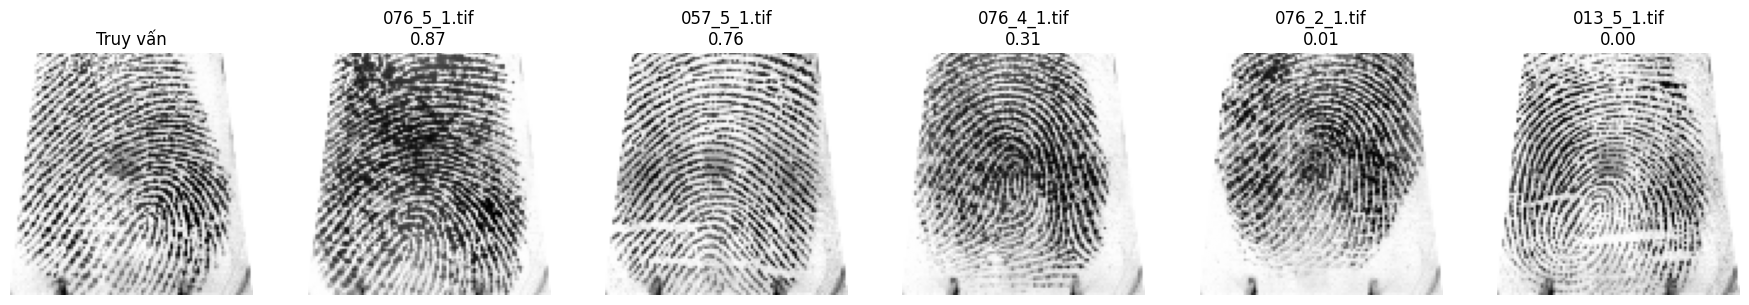

In [ ]:
query_path = "/content/drive/MyDrive/Fingerprint_Recognition/Datasets/Fingerprint/076_5_5.tif"

top_k = find_top_k_matches_batch(
    model=siamese_model,
    query_path=query_path,
    gallery_folder=gallery_path,
    img_size=100,
    top_k=5,
    show_images=True
)